# Домашнее задание

### ИАД. 2024-2025

### Прогнозирование временных рядов

Мы постарались составить домашнее задание так, чтобы оно помогло закрепить все то, что мы прошли за 2 недели на лекциях и семинарах. Вы вольны использовать любые библиотеки, которые вам нравятся. Главное — это осознанность в выборе методов и интерпретации выводов. 

В рамках домашнего задания будем работать с датасетом `NN5`, который можно скачать [здесь](https://zenodo.org/records/4656117). Временные ряды в этом датасете представляют собой данные по ежедневным снятиям наличных в банкоматах в Великобритании. 

### Задание 1. Первичный анализ данных (1 балл)

In [47]:
# !pip install --upgrade pip wheel
# !pip install --upgrade matplotlib pandas plotly statsforecast ipywidgets
# !pip install numpy==1.26.4 scikit-learn==1.6.1 tsururu==1.0.1 nbformat==5.10.4 catboost==1.2.8

In [48]:
import logging

logger = logging.getLogger(__name__)
import sys

c_handler = logging.StreamHandler(sys.stdout)
logger.addHandler(c_handler)
logging.basicConfig(level=logging.INFO, force=True)

import random
import warnings
from datetime import datetime
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from statsforecast import StatsForecast, models
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

In [49]:
def mase(
    forecast: np.ndarray,
    insample: np.ndarray,
    outsample: np.ndarray,
    frequency: int,
) -> np.ndarray:
    """MASE loss as defined in "Scaled Errors" https://robjhyndman.com/papers/mase.pdf

    Args:
        forecast: Forecast values. Shape: batch, time_o
        insample: Insample values. Shape: batch, time_i
        outsample: Target values. Shape: batch, time_o
        frequency: Frequency value
    Returns:
        Same shape array with error calculated for each time step
    """
    return np.mean(np.abs(forecast - outsample)) / np.mean(
        np.abs(insample[:-frequency] - insample[frequency:])
    )

Нам пригодятся уже знакомые функции с семинаров по чтению рядов в формате tsf. Напомню, что иногда временные ряды могут быть представлены в tsf формате. Это такая структура данных, которая позволяет хранить метаинформацию о временных рядах, а также пары "первая дата — все значения временного ряда".

Функции позволяют считать данные в tsf формате и перевести их в формат, которым мы можем пользоваться.

In [50]:
def convert_tsf_to_dataframe(
    full_file_path_and_name: str,
    replace_missing_vals_with: Any = "NaN",
    value_column_name: str = "series_value",
) -> tuple[pd.DataFrame, str, int, str, str]:
    """
    Конвертирует файл формата TSF в pandas DataFrame.

    Args:
        full_file_path_and_name: Путь к файлу формата TSF.
        replace_missing_vals_with: Значение для замены пропусков.
        value_column_name: Имя столбца для значений временных рядов.

    Returns:
        DataFrame с данными временных рядов.
        Частота данных.
        Прогнозируемый горизонт.
        Содержат ли данные пропуски.
        Равны ли длины временных рядов.

    """
    col_names = []
    col_types = []
    all_data = {}
    all_series = []
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    data_started = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith("@"):
                if line.startswith("@data"):
                    data_started = True
                    # Инициализируем словарь для данных атрибутов
                    for col in col_names:
                        all_data[col] = []
                else:
                    parts = line.split(" ")
                    if line.startswith("@attribute"):
                        col_names.append(parts[1])
                        col_types.append(parts[2])
                    elif line.startswith("@frequency"):
                        frequency = parts[1]
                    elif line.startswith("@horizon"):
                        forecast_horizon = int(parts[1])
                    elif line.startswith("@missing"):
                        contain_missing_values = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
                    elif line.startswith("@equallength"):
                        contain_equal_length = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
            elif not line.startswith("#") and data_started:
                parts = line.split(":")
                # Последняя часть содержит значения ряда
                series_vals = parts[-1].split(",")
                numeric_series = [
                    replace_missing_vals_with if val == "?" else float(val) for val in series_vals
                ]
                all_series.append(pd.Series(numeric_series).array)
                # Преобразуем и сохраняем значения атрибутов
                for i in range(len(col_names)):
                    if col_types[i] == "numeric":
                        all_data[col_names[i]].append(int(parts[i]))
                    elif col_types[i] == "string":
                        all_data[col_names[i]].append(parts[i])
                    elif col_types[i] == "date":
                        all_data[col_names[i]].append(
                            datetime.strptime(parts[i], "%Y-%m-%d %H-%M-%S")
                        )

    all_data[value_column_name] = all_series
    loaded_data = pd.DataFrame(all_data)
    return loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length


def date_to_daterange(x: pd.Series, freq: str) -> pd.Series:
    """
    Преобразует временные метки в диапазон дат.

    Args:
        x: Временные метки.
        freq: Частота.

    Returns:
        pd.Series с диапазоном дат.

    """
    return pd.Series(pd.date_range(start=x.iloc[0], periods=len(x), freq=freq))


def convert_tsf_to_multivariate_or_standard_format(
    tsf_data_path: str,
    target_column: str = "series_value",
    date_from_column: str = "start_timestamp",
    id_column: str = "series_name",
    # one from ["multivariate", "standard"]
    format: str = "multivariate",
) -> pd.DataFrame:
    """
    Преобразует данные формата TSF в формат pandas DataFrame:
        если format == "standard" -> датафрейм с колонками "id", "date" и "value"
        если format == "multivariate" -> pivot таблица c date в качестве индекса,
            id в качестве колонок и значениями из value_column_name

    Args:
        tsf_data_path: Путь к файлу формата TSF.
        target_column: Имя столбца с целевой переменной.
        date_from_column: Имя столбца с переменной дат.
        id_column: Имя столбца с идентификаторами временных рядов.
        format: Формат данных ("multivariate" или "standard").

    Returns:
        pd.DataFrame с данными в формате "id", "date" и "value".

    """
    FREQ_MAP = {
        "monthly": "MS",
        "10_minutes": "10min",
        "half_hourly": "30min",
        "minutely": "1min",
        "daily": "D",
        "weekly": "7D",
        "yearly": "YS",
        "quarterly": "QS",
        "hourly": "H",
    }

    tsf_df, freq = convert_tsf_to_dataframe(tsf_data_path)[:2]

    # Преобразуем списки в {target_column} в "длинный столбец" со значениями
    tsf_df = tsf_df.explode(target_column)
    # Заменим повторяющиеся значения даты в {date_column} на date_range
    tsf_df["date"] = (
        tsf_df.groupby(id_column, sort=False)[date_from_column]
        .apply(lambda x: date_to_daterange(x, FREQ_MAP[freq]))
        .values
    )
    tsf_df = tsf_df.drop(columns=date_from_column)
    # Переименуем колонки
    tsf_df = tsf_df.rename(columns={id_column: "id", target_column: "value"}).reset_index(
        drop=True
    )
    # Приведем {id_column} к численным значениям
    ids2num = dict(zip(tsf_df["id"].unique(), np.arange(tsf_df["id"].nunique())))
    tsf_df["id"] = tsf_df["id"].map(ids2num)

    if format == "standard":
        return tsf_df
    return pd.pivot_table(tsf_df, values="value", index="date", columns="id")

#### Задание 1.1: Загрузка данных (0 баллов)

Давайте скачаем датасет __NN5__ и загрузим его, воспользовавшись функцией `convert_tsf_to_multivariate_or_standard_format`.

In [51]:
import os

if not os.path.exists("nn5_daily_dataset_without_missing_values.tsf"):
    !wget "https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1" -O nn5_daily_dataset_without_missing_values.zip
    !unzip -o nn5_daily_dataset_without_missing_values.zip
    !rm nn5_daily_dataset_without_missing_values.zip

In [52]:
df = convert_tsf_to_multivariate_or_standard_format(
    "nn5_daily_dataset_without_missing_values.tsf", format="standard"
)
df.head()

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.70805,1996-03-21
4,0,26.629819,1996-03-22


#### Задание 1.2: Типы данных (0.3 балла)

Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, id — object, а значения временных рядов — float. Если это не так, то исправьте их.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87801 entries, 0 to 87800
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      87801 non-null  int64         
 1   value   87801 non-null  object        
 2   date    87801 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.0+ MB


Приведём value к float:

In [54]:
df["value"] = df["value"].astype(float, errors="raise")

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87801 entries, 0 to 87800
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      87801 non-null  int64         
 1   value   87801 non-null  float64       
 2   date    87801 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.0 MB


id не приводится к object, т.к. он уже в формате int64

#### Задание 1.3: Пропуски (0.05 балла)

Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом.

Пропусков нет:

In [56]:
df.isna().sum()

id       0
value    0
date     0
dtype: int64

#### Задание 1.4: Визуальный анализ временных рядов (0.4 балла)

Постройте линейные графики временных рядов. По оси X отложите время, по оси Y — значения временного ряда.

Используйте Plotly, чтобы можно было отложить сразу все временные ряды на одном графике.

In [57]:
def plot_all_graphs(df: pd.DataFrame):
    fig = go.Figure()
    for graph_id, graph_df in df.groupby(by="id"):
        fig.add_trace(go.Scatter(x=graph_df.date, y=graph_df.value, name=f"Graph no {graph_id}"))
    fig.update_layout(xaxis_title="date", yaxis_title="value")
    fig.show()

def plot_random_subset_of_graphs(df: pd.DataFrame):
    fig = go.Figure()
    random_ids = np.random.choice(df.id.unique(), 6, replace=False)
    for graph_id in random_ids:
        graph_df = df[df.id == graph_id]
        fig.add_trace(go.Scatter(x=graph_df.date, y=graph_df.value, name=f"Graph no {graph_id}"))
    fig.update_layout(xaxis_title="date", yaxis_title="value")
    fig.show()

np.random.seed(0x45)
plot_random_subset_of_graphs(df)

__Ответьте на следующие вопросы:__
- Какова частотность (frequency) данных?
- Выровнены ли временные ряды?
- Стационарны ли временные ряды? Если нет, то какие признаки нестационарности вы можете выделить?
- На какие группы можно разбить временные ряды по наличию общих признаков? Есть ли что-то, чем похожи все временные ряды?
- Есть ли в рядах выбросы? Как вы можете это определить?

1. Судя по пикам, частотность данных $\approx$ 1 месяц
2. Да (i.e. они следуют одному паттерну изменения значения (value) с течением времени)
3. У рядов, кажется, не меняются мат. ожидания, но у ряда 66 меняется дисперсия, т.е. не все ряды стационарны
4. Ряды 8 и 81 относятся к группе рядов, у которых относительно небольшая дисперсия, а у рядов 13, 17, 64 и 81 относительно большая дисперсия, меняющаяся со временем
5. У ряда 66 виден выброс 1 ноября 1997 года (а также 19 сентября, 9 октября и 3 ноября того же года). Мат. ожидание 66 ряда $\approx$ 30, 95-й квантиль $\le$ 50, а значения в этих точках превышают 65 (аналогичные рассуждения для выбросов ниже мат. ожидания, например, 4 октября 1997 года)

#### Задание 1.5: Выделение тестовой выборки (0.25 балла)

Выделите 10% данных для теста, а остальные 90% оставьте для обучения. Делайте это очень аккуратно, чтобы не нарушить временную и многомерную структуру данных!

Вспомните и напишите, в чем особенность выделения тестовой выборки в задаче прогнозирования временных рядов и в задаче прогнозирования __многомерных__ временных рядов.

Обратите внимание, что временные ряды выровнены, а значит, в отличие от семинара, пробегаться в цикле по каждому id не нужно. Подумайте, как можно сделать это более эффективно.

In [58]:
def select_split_date(dates: pd.Series, p: float = 0.9):
    assert 0 < p < 1
    unique_dates = sorted(dates.unique())
    split_date_index = int(len(unique_dates) * p)
    return unique_dates[split_date_index]

split_date = select_split_date(df.date)
df_train: pd.DataFrame = df[df.date <= split_date].copy()
df_test: pd.DataFrame = df[df.date > split_date].copy()

assert df_train.date.max() < df_test.date.min()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train.date, y=df_train.value, name="train", line={"color": "green"}))
fig.add_trace(go.Scatter(x=df_test.date, y=df_test.value, name="test", line={"color": "red"}))
fig.update_layout(title="train/test split", xaxis_title="date", yaxis_title="value")
fig.show()

При разделении на train / test важно не допустить leak информации из будущего в train подвыборку, иначе, если при обучении модель будет предиктить value, зная value в будущем, это может ухудшить качество модели (т.к. при инференсе у нас уже не будет данных из будущего)

Аналогично, при разделении многомерного временного ряда важно выбрать единый таймстемп в качестве разделителя для всех одномерных рядов в многомерном ряде, чтобы не допустить leak данных из будущего в train подвыборку

### Задание 2. Полный анализ одного временного ряда (4 баллов)

#### Задание 2.1: Визуальный анализ (0.5 балла)

Выделите из данных временной ряд с номером 92. Постройте его линейный график.

In [59]:
series_92: pd.DataFrame = df[df.id == 92]
fig = go.Figure()
fig.add_trace(go.Scatter(x=series_92.date, y=series_92.value, name=f"Graph no 92"))
fig.update_layout(xaxis_title="date", yaxis_title="value")
fig.show()

Постройте графики автокорреляций (ACF) и частных автокорреляций (PACF) до 40-го лага для тренировочной выборки.

In [60]:
def plot_acf_pacf(values, lags=40):
    _fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(values, lags=lags, ax=ax[0])
    plot_pacf(values, lags=lags, ax=ax[1])
    plt.show()


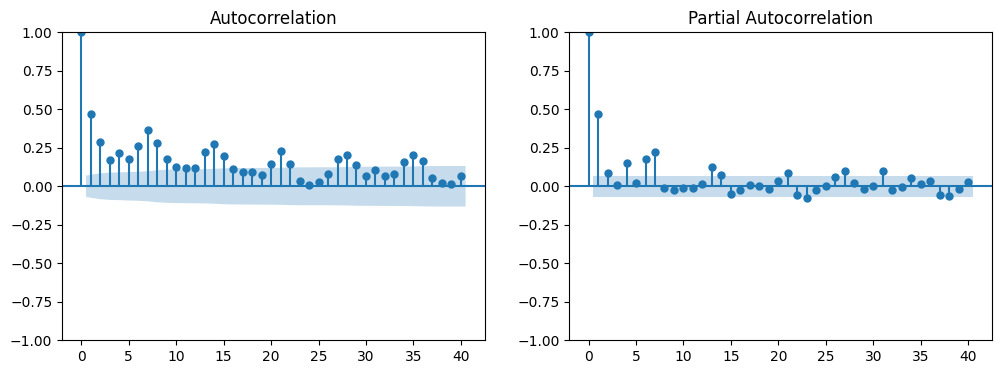

In [61]:
plot_acf_pacf(np.log1p(series_92.value))

__Ответьте на следующие вопросы:__
- Стационарен ли временной ряд?
- Присутствует ли в нём тренд? Сезонность? Цикличность?
- Если ряд сезонный, то какой период выглядит наиболее вероятным?

1. Ряд не стационарен (у 92 ряда растёт мат. ожидание и не постоянна дисперсия)
2. У 92 ряда есть тренд (выглядит как аддитивный). Есть сезонность (похожа на мультипликативную). Есть циклы, например:
- Рост и спад с 4 апреля 1996 до 14 августа 1996
- Рост и спад с 14 августа 1996 до 31 декабря 1996
- Рост и спад с 31 декабря 1996 до 30 марта 1997
- etc.
3. Период в 1 месяц выглядит наиболее вероятным

#### Задание 2.2: Построение модели SARIMA (2 балла)

Пользуясь правилами отсюда: https://people.duke.edu/~rnau/arimrule.htm, попробуйте подобрать параметры SARIMA модели, как мы делали это на семинаре.

Не забудьте о возможности использовать предобработку данных, например, логарифмирование и удаление выбросов (самое простое — это воспользоваться IQR: https://medium.com/@divyansh9144/iqr-interquartile-range-for-anomaly-detection-f9c568d1195f).

Если вы используете предобработку, то обязательно укажите, какую именно и почему.

Уберём выбросы при помощи IQR (выбросы были видны при анализе графиков выше):

In [62]:
def get_outliers_indices(group_df: pd.DataFrame):
    values: pd.Series = group_df.value
    Q1: float = values.quantile(0.25)
    Q3: float = values.quantile(0.75)
    IQR: float = Q3 - Q1
    K = 2
    lower_bound = Q1 - K * IQR    
    upper_bound = Q3 + K * IQR
    return group_df[(values < lower_bound) | (values > upper_bound)].index

outlier_indicies = set()
for group_id, group_df in df_train.groupby(by="id"):
    outlier_indicies |= set(get_outliers_indices(group_df))

print(f"Total: {len(outlier_indicies)} outliers")

Total: 384 outliers


In [63]:
print(f"Before drop: {len(df_train)} values")
df_train.drop(index=outlier_indicies, inplace=True)
print(f"After drop: {len(df_train)} values")

Before drop: 79032 values
After drop: 78648 values


Сделаем логарифмирование данных (для стабильности вычислений, т.к. float'ы работают стабильнее при меньшем масштабе, чем 10-ки)

Используем $\log(1 + p)$, т.к. есть значения, равные 0

In [64]:
assert (df_train.value >= 0).all()
assert (df_train.value == 0).any()
df_train["log_value"] = np.log1p(df_train.value)

In [65]:
df_train.head()

,id,value,date,log_value
0,0,13.407029,1996-03-18,2.667716
1,0,14.725057,1996-03-19,2.755255
2,0,20.564059,1996-03-20,3.071028
3,0,34.708050,1996-03-21,3.575376
4,0,26.629819,1996-03-22,3.318896


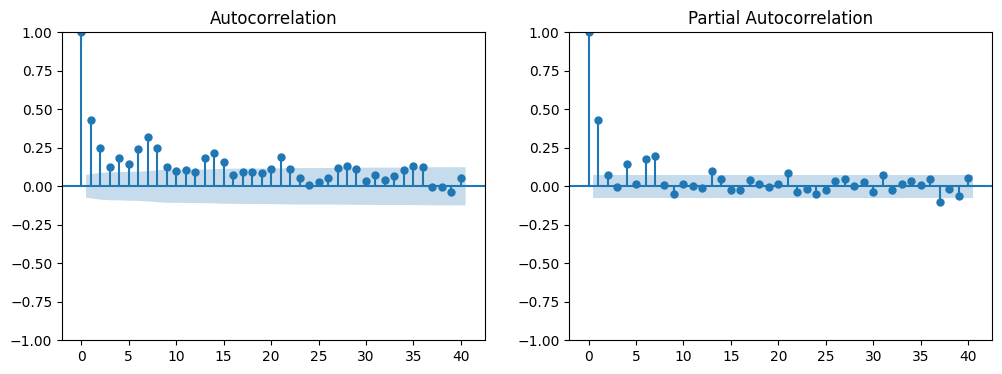

In [66]:
series_92_train: pd.DataFrame = df_train[df_train.id == 92]
series_92_train_log_value: pd.Series = series_92_train.log_value
plot_acf_pacf(series_92_train_log_value)

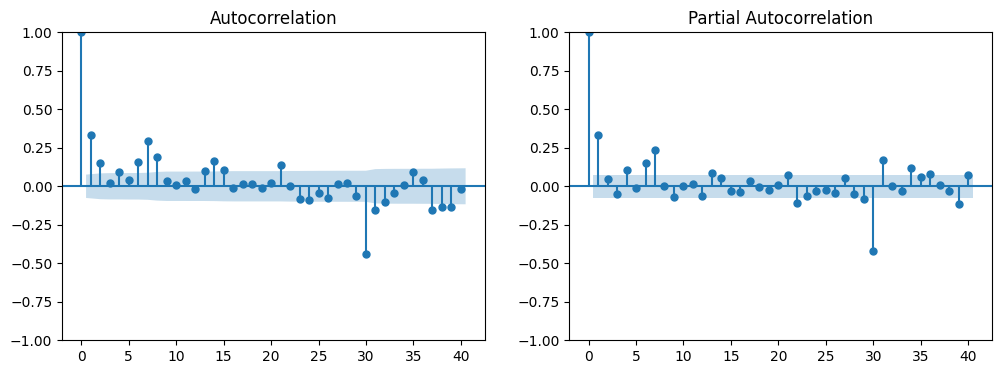

In [67]:
series_92_train_log_value_diff = series_92_train_log_value.diff(periods=31)
series_92_train_log_value_diff.dropna(inplace=True)
plot_acf_pacf(series_92_train_log_value_diff)

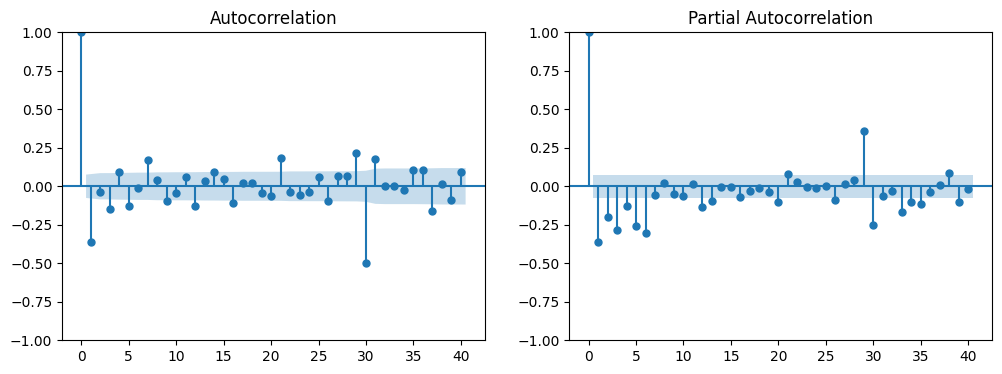

In [68]:
series_92_train_log_value_diff_diff = series_92_train_log_value_diff.diff()
series_92_train_log_value_diff_diff.dropna(inplace=True)
plot_acf_pacf(series_92_train_log_value_diff_diff)

In [69]:
print(f"Standart deviations:\n"
      f"Diff = 0: {series_92_train_log_value.std()}\n"
      f"Diff = 1: {series_92_train_log_value_diff.std()}\n"
      f"Diff = 2: {series_92_train_log_value_diff_diff.std()}")

Standart deviations:
Diff = 0: 0.40746752363709793
Diff = 1: 0.5679898704842796
Diff = 2: 0.6562514396302617


- Судя по графику автокорреляции, нужен более высокий порядок дифференцирования ($\implies d \ge 1$) (правило 1, не противоречит правилу 2)
- При двойном дифференцировании сильно растёт std $\implies d < 2$ (правило 2)
- По правилу 5 и т.к. $d = 1$ и у значений есть ненулевой тренд, у модели должен быть bias член (constant term)
- Судя по графику частивной автокорреляции, нужен AR = p = 1 (правило 6)
- Судя по графику автокорреляции, нужен MA = q = 1 (правило 7)

In [75]:
pdq = (1, 1, 1)
period = 31
print_convergence_messages = False

model = SARIMAX(
    series_92_train_log_value,
    order=pdq,
    seasonal_order=(*pdq, period),
).fit(disp=print_convergence_messages)

                                     SARIMAX Results                                      
Dep. Variable:                          log_value   No. Observations:                  698
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 31)   Log Likelihood                -311.918
Date:                            Mon, 19 May 2025   AIC                            633.836
Time:                                    17:07:24   BIC                            656.342
Sample:                                         0   HQIC                           642.556
                                            - 698                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3120      0.034      9.208      0.000       0.246       0.378
ma.L1         -0.9414      0.017   

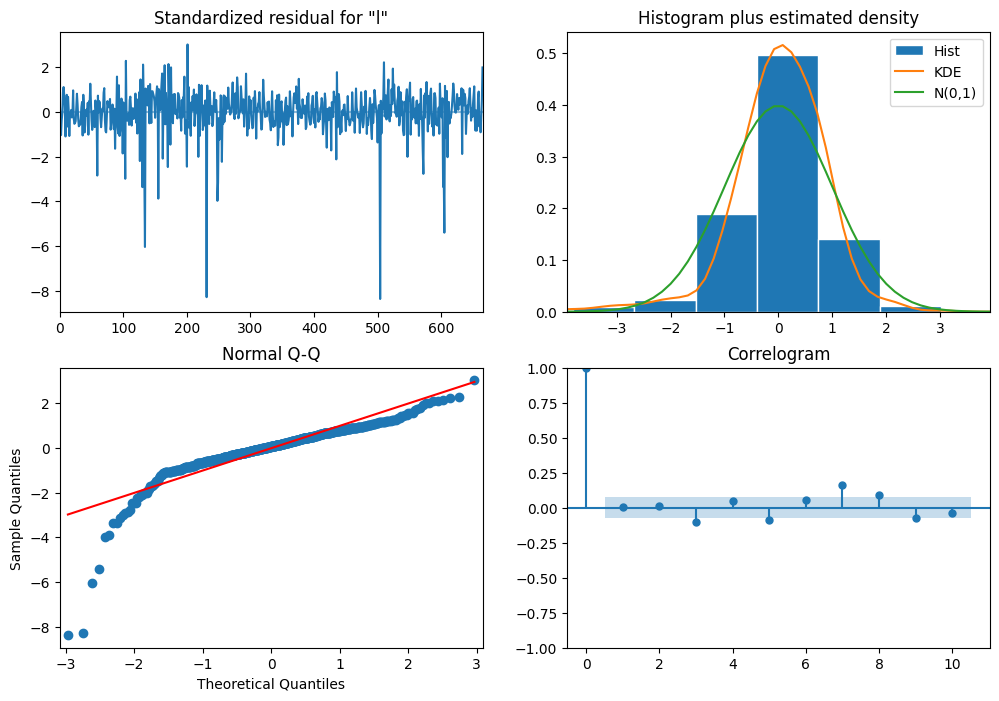

In [76]:
print(model.summary())
model.plot_diagnostics(figsize=(12, 8))
plt.show()

#### Задание 2.3: Анализ остатков (0.5 баллов)

Постройте графики ACF и PACF остатков модели SARIMA. Проверьте, что в остатках нет значимых автокорреляций. Если они есть, то попробуйте объяснить, почему это происходит.

Проведите тест на стационарность остатков модели. Проведите тест на автокорреляцию остатков модели. Проинтерпретируйте результаты тестов. Если тесты показывают, что остатки нестационарны или в них есть автокорреляция, то попробуйте объяснить, почему это происходит.

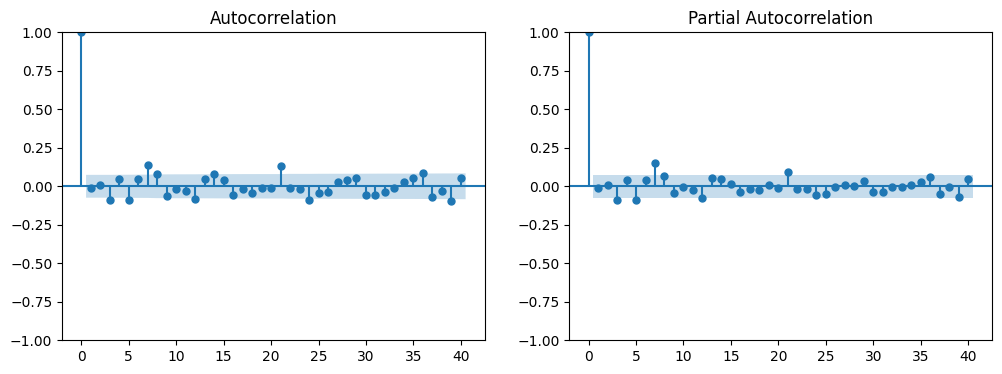

In [77]:
residuals = model.resid
plot_acf_pacf(residuals)

В остатках есть автокорреляция только при лаге 0 (отступа нет, а значение в точке всегда коррелирует само с собой)

Критерий Квятковского-Филлипса-Шмидта-Шина:

$H_0$: остатки стационарны

In [78]:
statistic, p_value, lags, critical_values = kpss(residuals)
print(f"p-value: {p_value}")

p-value: 0.1


Гипотеза $H_0$ принимается, остатки стационарны

Тест Дики — Фуллера:

$H_0$: остатки не стационарны

In [79]:
statistic, p_value, usedlag, _, critical_values, icbest = adfuller(residuals)
print(f"p-value: {p_value}")

p-value: 1.2810860719884619e-11


Гипотеза $H_0$ отвергается, принимается альтернатива $H_1$, остатки стационарны

Тест Льюнг–Бокса:

$H_0$: автокорреляция отсутствует

In [80]:
acorr_ljungbox(residuals, lags=list(range(1, 11)), return_df=True)

,lb_stat,lb_pvalue
1,0.098537,0.753593
2,0.127010,0.938469
3,5.421133,0.143433
4,6.828575,0.145229
5,12.312413,0.030749
6,13.818085,0.031736
7,27.367999,0.000286
8,31.665129,0.000107
9,34.215692,0.000082
10,34.383533,0.000159


При лаге $\ge 5$ гипотеза $H_0$ отвергается (на уровне значимости $0.05$), т.е. присутствует автокорреляция. Возможно, неправильно выбран период (в месяце не ровно 30 дней, а выбранный период = 30 дней)

#### Задание 2.4: Получение прогнозов и выводы (1 балл)

С помощью полученной модели постройте прогноз на тестовую выборку. 

Постройте график прогноза и фактических значений. Сделайте выводы о том, насколько хорошо модель предсказывает временной ряд. 

Посчитайте метрику MASE, которую мы имплементировали в начале ноутбука. Объясните, что она показывает и почему ее потенциально полезнее использовать для сравнения моделей, чем MAE или MAPE. Выводы по самому значению метрики делать не нужно.

In [81]:
series_92_test: pd.DataFrame = df_test[df_test.id == 92]
forecast = np.expm1(model.get_forecast(steps=len(series_92_test.value)).predicted_mean.values)
fig = go.Figure()
fig.add_trace(go.Scatter(x=series_92_test.date, y=series_92_test.value, name="ground truth", line={"color": "green"}))
fig.add_trace(go.Scatter(x=series_92_test.date, y=forecast, name="forecast", line={"color": "red"}))
fig.update_layout(xaxis_title="date", yaxis_title="value")
fig.show()

Модель плохо предсказывает временной ряд

In [82]:
error = mase(
    forecast=forecast,
    insample=series_92_train.value.values,
    outsample=series_92_test.value.values,
    frequency=period,
)
print(f"MASE: {error}")

MASE: 0.9295640928062349


Метрика MASE показвает, лучше ли модель наивного подхода. Значения > 1 показывают, что алгоритм хуже наивного подхода, а значения < 1 - что лучше

Плюсы метрики:
- Метрика не зависит от масштабов данных (в отличие от MSE)
- Симметрична (одинаково штрафует predit > ground_truth и predict < ground_truth, в отличие от MAE)

### Задание 3. Построение бейзлайнов на всех рядах и автоматический подбор параметров (2 балла)

#### Задание 3.1: Запуск бейзлайнов (1 балл)
Давайте будем использовать statsforecast для бейзлайнов, так же как мы делали это на семинаре: https://nixtlaverse.nixtla.io/statsforecast/index.html 

Постройте прогнозы на всех рядах с помощью следующих бейзлайнов:
- Naive
- Seasonal Naive
- AutoARIMA
- еще 2 на ваш выбор (например, ETS, Theta, TBATS или другие, которые вам нравятся). Кратко опишите суть выбранных моделей.

In [83]:
column_mapper = {"date": "ds", "id": "unique_id", "value": "y"}
df_train_sf = df_train.copy(deep=True)
df_train_sf.rename(axis="columns", mapper=column_mapper, inplace=True)
df_train_sf.drop(columns="log_value", inplace=True)
df_train_sf

,unique_id,y,ds
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.708050,1996-03-21
4,0,26.629819,1996-03-22
...,...,...,...
87717,110,10.915308,1998-02-23
87718,110,14.452920,1998-02-24
87719,110,18.279853,1998-02-25
87720,110,27.472383,1998-02-26


In [84]:
df_test_sf = df_test.copy(deep=True)
df_test_sf.rename(axis="columns", mapper=column_mapper, inplace=True)
df_test_sf

,unique_id,y,ds
712,0,33.489229,1998-02-28
713,0,18.608277,1998-03-01
714,0,24.333900,1998-03-02
715,0,26.927438,1998-03-03
716,0,40.717120,1998-03-04
...,...,...,...
87796,110,18.016833,1998-05-13
87797,110,25.157812,1998-05-14
87798,110,22.080484,1998-05-15
87799,110,10.113098,1998-05-16


- Theta выделяетиз ряда сезонность и считает на её основе $\theta$ ряды для учитывания разных видов локальной кривизны ряда

- TBABS поддерживает множественную сезоность, возможно, это важно учитывать в данном многомерном ряде

In [100]:
sf = StatsForecast(
    models=[
        models.SeasonalNaive(season_length=period),
        models.Naive(),
        models.AutoARIMA(season_length=period),
        models.AutoTheta(season_length=period),
        models.AutoTBATS(season_length=period),
    ],
    freq='D',
    n_jobs=-1,
    verbose=True,
)

In [114]:
horizon_ts = (df_test_sf.ds.max() - df_test_sf.ds.min())
horizon_ts

Timedelta('78 days 00:00:00')

In [115]:
horizon = horizon_ts.days

In [ ]:
forecast_df = sf.forecast(h=horizon, df=df_train_sf)

Forecast:   0%|          | 0/111 [Elapsed: 00:00]

#### Задание 3.2: Анализ результатов (1 балл)

Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Выведите метрики MASE. 

Что можно сказать о каждом из бейзлайнов? Какой из бейзлайнов лучше всего предсказывает временной ряд?

Смогли ли вы руками подобрать гиперпараметры для SARIMA модели лучше, чем автоматический подбор в библиотеке? Если да, то вы огромный молодец! Если нет, то не расстраивайтесь, так бывает.

In [138]:
series_92_train_sf: pd.DataFrame = df_train_sf[df_train_sf.unique_id == 92]
series_92_test_sf: pd.DataFrame = df_test_sf[df_test_sf.unique_id == 92]
forecast_series_92: pd.DataFrame = forecast_df[forecast_df.unique_id == 92]

fig = go.Figure()
MODEL_NAMES = ("SeasonalNaive", "Naive", "AutoARIMA", "AutoTheta", "AutoTBATS")
for model_name in MODEL_NAMES:
    model_preds: pd.Series = forecast_series_92[model_name]
    fig.add_trace(go.Scatter(x=forecast_series_92.ds, y=model_preds, name=f"Model {model_name}"))
    error = mase(
        forecast=model_preds.values,
        insample=series_92_train_sf.y.values,
        outsample=series_92_test_sf.y.values,
        frequency=period,
    )
    print(f"Model {model_name}:\n\tMASE = {error}")

fig.add_trace(go.Scatter(x=series_92_test_sf.ds, y=series_92_test_sf.y, name=f"Ground truth"))
fig.update_layout(xaxis_title="date", yaxis_title="value")
fig.show()

Model SeasonalNaive:
	MASE = 1.2334598437052275
Model Naive:
	MASE = 1.743835592728866
Model AutoARIMA:
	MASE = 0.7735342154278964
Model AutoTheta:
	MASE = 0.8980149871960007
Model AutoTBATS:
	MASE = 0.7768149506888811


Модели ARIMA, Theta и TBATS оказали лучше (по метрике MASE), чем обученная до этого модель, однако Theta модель обучилась выдавать константу
Лучше всего предсказывает ARIMA (но почти также, как)


Постройте датафрейм с MASE для всех бейзлайнов (агрегированный по всем рядам). Какой из бейзлайнов лучше всего предсказывает временные ряды в нашем датасете? Какой из бейзлайнов хуже всего предсказывает временные ряды в нашем датасете? Как вы думаете, почему так происходит? 

In [144]:
fig = go.Figure()
model_errors = {model_name: [] for model_name in MODEL_NAMES}
for series_id, series_forecast in forecast_df.groupby(by="unique_id"):
    for model_name in MODEL_NAMES:
        model_preds: pd.Series = series_forecast[model_name]
        fig.add_trace(go.Scatter(x=series_forecast.ds, y=model_preds, name=f"Model {model_name}, series id = {series_id}"))
        model_errors[model_name].append(mase(
            forecast=model_preds.values,
            insample=df_train_sf[df_train_sf.unique_id == series_id].y.values,
            outsample=df_test_sf[df_test_sf.unique_id == series_id].y.values,
            frequency=period,
        ))

for model_name in MODEL_NAMES:
    print(f"Model {model_name}:\n\tAverage MASE = {np.mean(model_errors[model_name])}")

fig.update_layout(xaxis_title="date", yaxis_title="value")
fig.show()

Model SeasonalNaive:
	Average MASE = 0.971537423341123
Model Naive:
	Average MASE = 1.3308815522137345
Model AutoARIMA:
	Average MASE = 0.6341811442455527
Model AutoTheta:
	Average MASE = 0.7354182994894455
Model AutoTBATS:
	Average MASE = 0.6847385911021354


Лучше всего - ARIMA, хуже всего - наивный подход

Возможно, наивный подход оказался хуже всего, т.к. он не учитывает сильную волатильность данных и сезонность

Возможно, ARIMA оказалсь лучше Theta и TBATS, т.к. в данных нет признаков, которые Theta умеет выделять лучше, чем другие модели (разные виды кривизны данных), и в данных, возможно, нет множественной сезоности или она оказалась менее важной, чем другие признаки, которые выделила ARIMA

Постройте графики фактических значений и прогнозов самого сильного бейзлайна для еще 3-х каких-нибудь рядов и ответьте на следующие вопросы:
- Есть ли среди них такие, которые предсказываются хуже остальных?
- Есть ли среди них такие, которые предсказываются лучше остальных? 

In [146]:
fig = go.Figure()
for series_id, series_forecast in forecast_df.groupby(by="unique_id"):
    if series_id not in {0, 1, 2}:
        continue

    model_name = "AutoARIMA"
    model_preds: pd.Series = series_forecast[model_name]
    fig.add_trace(go.Scatter(x=series_forecast.ds, y=model_preds, name=f"Model {model_name}, series id = {series_id}"))
    fig.add_trace(go.Scatter(x=series_forecast.ds, y=df_test_sf[df_test_sf.unique_id == series_id].y.values, name=f"Ground truth, series id = {series_id}"))

fig.update_layout(xaxis_title="date", yaxis_title="value")
fig.show()

Во всех графиках модель предсказывает достаточно плохо: повторяет сезонность и точки пиков, но сильно сглаживает предикты

### Задание 4. ML & DL модели (3 балла)

Здесь хочется дать вам полную свободу действий.

Вам нужно будет выбрать одну из ML моделей и одну из DL моделей (старайтесь не повторять один в один решение из семинара, а, если повторяете, то попробуйте, например, перебрать параметры DL модели, оптимизации, препроцессинга / добавить экзогенные признаки (актуально для MIMO стратегии) и т. д.) и построить прогнозы для всех временных рядов на тестовой выборке. __Ваша цель (желательная, но необязательная) — улучшить MASE, полученный с помощью бейзлайнов.__ 

__Результат задания — мини-отчет по тому, что вы попробовали, что получилось и что не получилось.__ По одному баллу дается за работу с данными (предобработка, генерация дополнительных признаков), за применение ML и DL моделей и интерпретацию полученных с помощью них результатов. Не забудьте кратко описать суть выбранных моделей (особенно, если речь идет о DL моделях).

Вы можете использовать любые модели и библиотеки (`tsfresh` для извлечения признаков, `Tsururu` / `ETNA` / `darts` для использования предобработки, стратегий, моделей и т. д.).

In [ ]:
from tsururu.dataset import Pipeline, TSDataset
from tsururu.model_training.trainer import DLTrainer, MLTrainer
from tsururu.model_training.validator import KFoldCrossValidator
from tsururu.models.boost import CatBoost
from tsururu.strategies import RecursiveStrategy

In [166]:
df_train_ml = df_train.copy()
assert (df_train_ml.value >= 0).all()
assert (df_train_ml.value == 0).any()
df_train_ml["log_value"] = np.log1p(df_train_ml.value)

df_test_ml = df_test.copy()
assert (df_test_ml.value >= 0).all()
assert (df_test_ml.value == 0).any()
df_test_ml["log_value"] = np.log1p(df_test_ml.value)

In [167]:
dataset_params = {
    "target": {"columns": ["value"]},
    "date": {"columns": ["date"]},
    "id": {"columns": ["id"]},
}

train_dataset = TSDataset(
    data=df_train_ml,
    columns_params=dataset_params,
)
test_dataset = TSDataset(
    data=df_test_ml,
    columns_params=dataset_params,
)

HISTORY = min(60, (df_train_ml.date.max() - df_train_ml.date.min()).days + 1)
HORIZON = min(30, (df_test_ml.date.max() - df_test_ml.date.min()).days + 1)

INFO:tsururu.dataset.dataset:freq: Day; period: 1
                It seems that the data is not regular. Please, check the data and the frequency info.                
                For multivariate regime it is critical to have regular data.
                For global regime each regular part of time series will be processed as separate time series.           
                
INFO:tsururu.dataset.dataset:freq: Day; period: 1


In [168]:
def multivar_average_mase(train_df: pd.DataFrame, test_df: pd.DataFrame, forecast_df: pd.DataFrame, period: int):
    return np.mean([float(mase(
        forecast=forecast_df[forecast_df.id == series_id].value.values,
        insample=train_df[train_df.id == series_id].value.values,
        outsample=series.value.values,
        frequency=period,
    ) for series_id, series in test_df.groupby(by="id"))])


In [169]:
results = {}
preds = {}

for transformer in ("standard_scaler", "robust_scaler"):
    pipeline_easy_params = {
        "target_lags": HISTORY,
        "date_lags": 1,
        "target_normalizer": transformer,
        "target_normalizer_regime": "none",
        "normalizer_regime": "none",
    }

    pipeline = Pipeline.easy_setup(dataset_params, pipeline_easy_params, multivariate=False)

    trainer = MLTrainer(model=CatBoost, model_params={"task_type": "GPU"}, validator=lambda: KFoldCrossValidator(n_splits=5))
    strategy = RecursiveStrategy(horizon=HORIZON, model_horizon=4, history=HISTORY, pipeline=pipeline, trainer=trainer)

    fit_time, _ = strategy.fit(train_dataset)
    forecast_time, current_pred = strategy.predict(test_dataset)

    results[f"{transformer}_mae"] = multivar_average_mase(train_df=df_train, test_df=df_test, forecast_df=current_pred)
    preds[f"{transformer}_preds"] = current_pred

CatBoostError: catboost/cuda/train_lib/train_template_pointwise_greedy_subsets_searcher.h:34: Only plain boosting is supported in current mode

Не получилось (


Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Постройте графики фактических значений и прогнозов для 3-х рядов из предыдущего задания. Стали ли прогнозы лучше отражать реальность?

In [ ]:
# --- Your code here --